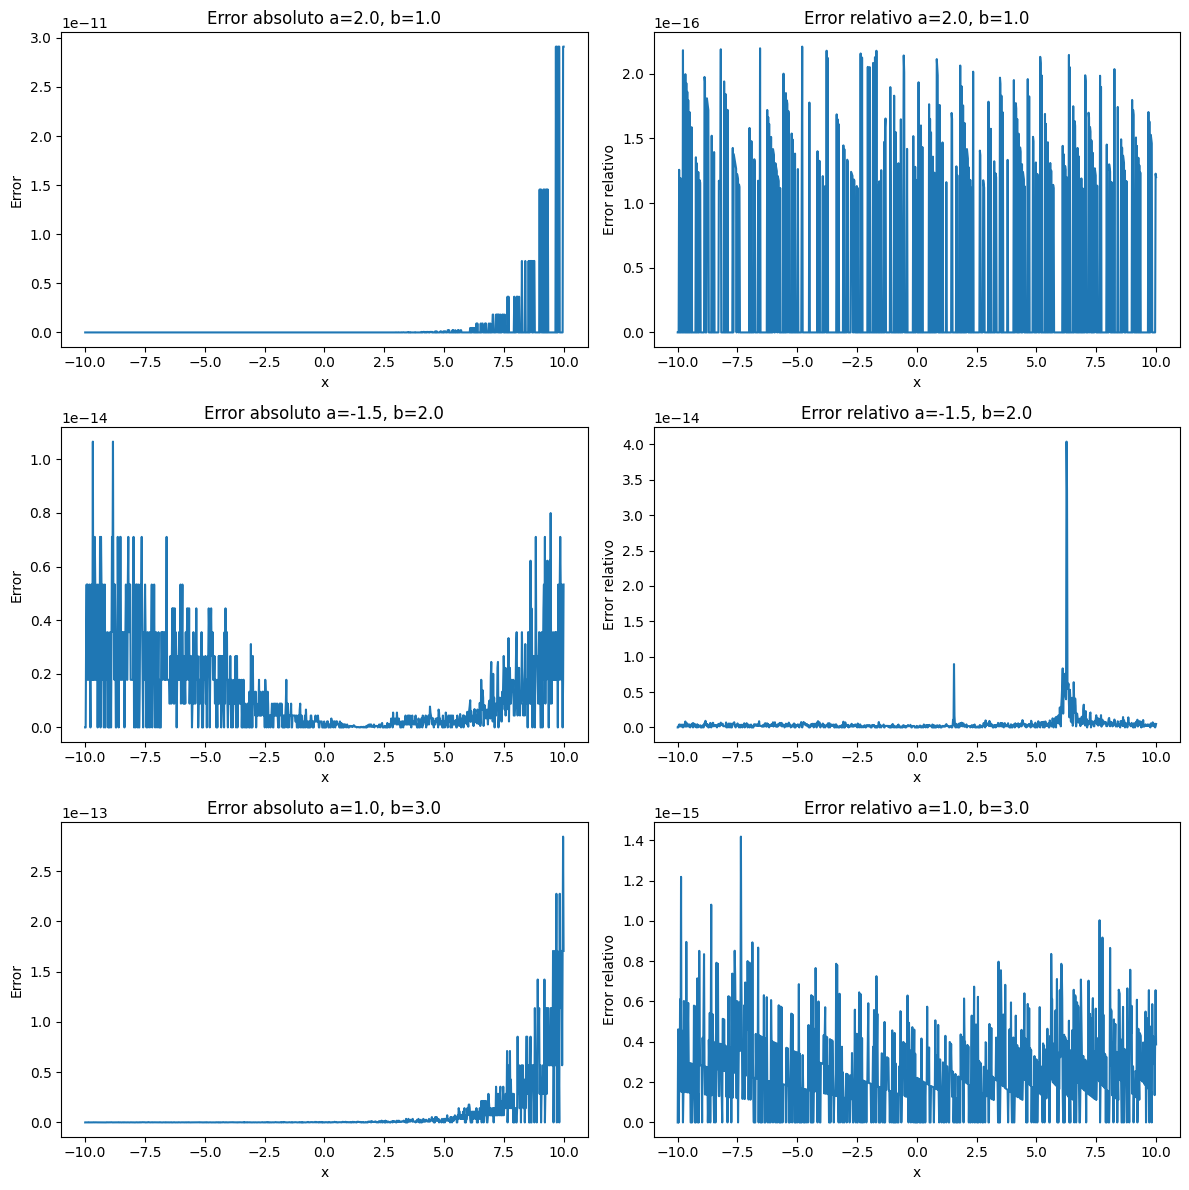

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import scipy.special

mpmath.mp.dps = 50  # Precisión alta con mpmath

x_values = np.linspace(-10, 10, 1000)

# Conjuntos de parámetros (a, b) con diferentes características
parametros = [
    (2.0, 1.0),      # a > b, ambos positivos
    (-1.5, 2.0),     # a negativo, b positivo
    (1.0, 3.0),      # a < b, ambos positivos
]

fig, axes = plt.subplots(len(parametros), 2, figsize=(12, 4 * len(parametros)))

for i, (a, b) in enumerate(parametros):
    resultados_mpmath = [mpmath.hyp1f1(a, b, x) for x in x_values]
    resultados_mpmath_float = [float(val.real) for val in resultados_mpmath]
    resultados_scipy = scipy.special.hyp1f1(a, b, x_values)

    error_absoluto = np.abs(np.array(resultados_mpmath_float) - resultados_scipy)
    error_relativo = error_absoluto / (np.abs(resultados_mpmath_float) + 1e-12)

    axes[i, 0].plot(x_values, error_absoluto)
    axes[i, 0].set_title(f'Error absoluto a={a}, b={b}')
    axes[i, 0].set_xlabel('x')
    axes[i, 0].set_ylabel('Error')

    axes[i, 1].plot(x_values, error_relativo)
    axes[i, 1].set_title(f'Error relativo a={a}, b={b}')
    axes[i, 1].set_xlabel('x')
    axes[i, 1].set_ylabel('Error relativo')

plt.tight_layout()
plt.show()


In [ ]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 1) / 2 + sp.I * (2*N + 1) / 2
            den = (s + 2) * (s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading}  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


N=6 -> a_std=6.5  | scale C=(1+0j)
max abs error on grid: 2263.582099042957


In [31]:
import sympy as sp

def build_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, N, 2):  
            num = sp.I*(2*s + 1)/2 - sp.I*(2*N + 1)/2   
            den = (s + 2)*(s + 1)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])

    return coeffs, leading

def normalized_coeffs_sympy(N):
    coeffs, leading = build_coeffs_sympy(N)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs], leading

def poly_string_sympy(N, var="x"):
    coeffs_norm, leading = normalized_coeffs_sympy(N)
    leading_name = 'a0' if N % 2 == 0 else 'a1'
    terms = []
    for s, cs in enumerate(coeffs_norm):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(var if s == 1 else "1")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    return (f"f_{N}({var}) = {leading_name}  (" + " + ".join(terms) + ")").replace("I","i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=-1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=-1/4

f_1(x) = a1  (x)
f_2(x) = a0  (1 + (-i)x^2)
f_3(x) = a1  (x + (-i/3)x^3)
f_4(x) = a0  (1 + (-2*i)x^2 + (-1/3)x^4)
f_5(x) = a1  (x + (-2*i/3)x^3 + (-1/15)x^5)
f_6(x) = a0  (1 + (-3*i)x^2 + (-1)x^4 + (i/15)x^6)
f_7(x) = a1  (x + (-i)x^3 + (-1/5)x^5 + (i/105)x^7)


In [30]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (i)x^2 + (-1/5)x^4 + (-i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


In [12]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')

    coeffs = [sp.Integer(0)] * (2*N + 1)

    if N % 2 == 0:  
        coeffs[0] = leading
        coeffs[1] = sp.Integer(0)
        for s in range(0, 2*N, 2):
            num = sp.I * (2*s + 3) / 2 - sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    else:  
        coeffs[0] = sp.Integer(0)
        coeffs[1] = leading
        for s in range(1, 2*N-1, 2):
            num = -sp.I * (2*s + 3) / 2 + sp.I * (2*N + 3) / 2
            den = (s + 3) * (s + 2)
            coeffs[s+2] = sp.simplify((num/den) * coeffs[s])
    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0') if N % 2 == 0 else sp.symbols('a1')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="x"):
    leading = 'a0' if N % 2 == 0 else 'a1'
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if (N % 2 == 0 and s == 0) or (N % 2 == 1 and s == 1):
            terms.append(f"{var if s==1 else '1'}")
        else:
            terms.append(f"({sp.simplify(cs)}){var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = {leading} ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=1, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=1, beta=1/4

f_1(x) = a1 (x)
f_2(x) = a0 (1 + (-i/3)x^2)
f_3(x) = a1 (x + (i/6)x^3)
f_4(x) = a0 (1 + (-2*i/3)x^2 + (-1/15)x^4)
f_5(x) = a1 (x + (i/3)x^3 + (-1/45)x^5)
f_6(x) = a0 (1 + (-i)x^2 + (-1/5)x^4 + (i/105)x^6)
f_7(x) = a1 (x + (i/2)x^3 + (-1/15)x^5 + (-i/420)x^7)


Polinomios asociados a la ec. hipergeometrica confluente

In [6]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(0, N):  # paso 1
        num = -(s*(s-1) + s + sp.Rational(3,4) - 2*sp.I*((N*(N-1)) + N+ sp.Rational(3,4)))
        den = (s + 1)
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1 + -3/4 + 7*i/2u^1)
f_2(u) = a0  (1 + -3/4 + 19*i/2u^1 + -1423/32 - 95*i/8u^2)
f_3(u) = a0  (1 + -3/4 + 39*i/2u^1 + -6063/32 - 195*i/8u^2 + 58679/128 - 76349*i/64u^3)
f_4(u) = a0  (1 + -3/4 + 67*i/2u^1 + -17935/32 - 335*i/8u^2 + 520325/384 - 396305*i/64u^3 + 99445515/2048 + 20307365*i/768u^4)
f_5(u) = a0  (1 + -3/4 + 103*i/2u^1 + -42415/32 - 515*i/8u^2 + 1230245/384 - 1449725*i/64u^3 + 581293515/2048 + 74083265*i/768u^4 + -47785843447/24576 + 31953076223*i/12288u^5)
f_6(u) = a0  (1 + -3/4 + 147*i/2u^1 + -86415/32 - 735*i/8u^2 + 835415/128 - 4225025*i/64u^3 + 2451733515/2048 + 71895495*i/256u^4 + -66672869949/8192 + 68227366809*i/4096u^5 + -11083462026315/65536 - 2804721777305*i/16384u^6)
f_7(u) = a0  (1 + -3/4 + 199*i/2u^1 + -158383/32 - 995*i/8u^2 + 4593317/384 - 10493469*i/64u^3 + 8293088203/2048 + 535451489*i/768u^4 + -3371788269779/122880 + 4807472658139*i/61440u^5 + -3479454044091407/2949120 - 64786419415241*i/81920u^6 + 47991

In [7]:
import sympy as sp

def build_coeffs_sympy(N, leading=None):
    if leading is None:
        leading = sp.symbols('a0')  # ya no necesitamos a1

    coeffs = [sp.Integer(0)] * (N + 1)
    coeffs[0] = leading

    a_tr = -2*sp.I*(N*(N-1) + N + sp.Rational(3,4))

    for s in range(1, N):  # paso 1
        num = -(s + sp.Rational(1,4) - 2*sp.I*((N + sp.Rational(1,4))))
        den = (s + 1) * s
        coeffs[s+1] = sp.simplify((num/den) * coeffs[s])

    return coeffs

def normalized_coeffs_sympy(N):
    leading = sp.symbols('a0')
    coeffs = build_coeffs_sympy(N, leading=leading)
    return [sp.simplify(c/leading) if c != 0 else sp.Integer(0) for c in coeffs]

def poly_string_sympy(N, var="u"):
    coeffs = normalized_coeffs_sympy(N)
    terms = []
    for s, cs in enumerate(coeffs):
        if cs == 0:
            continue
        if s == 0:
            terms.append("1")
        else:
            terms.append(f"{sp.simplify(cs)}{var}^{s}")
    poly_str = " + ".join(terms)
    return (f"f_{N}({var}) = a0  ({poly_str})").replace("I", "i")

if __name__ == "__main__":
    print("Polinomio asociado a alpha=0, beta=1/4\n")
    N_max = 7
    for N in range(1, N_max+1):
        print(poly_string_sympy(N))


Polinomio asociado a alpha=0, beta=1/4

f_1(u) = a0  (1)
f_2(u) = a0  (1)
f_3(u) = a0  (1)
f_4(u) = a0  (1)
f_5(u) = a0  (1)
f_6(u) = a0  (1)
f_7(u) = a0  (1)


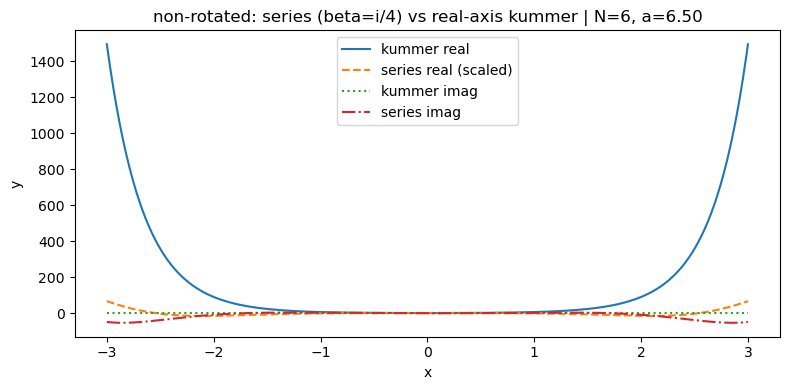

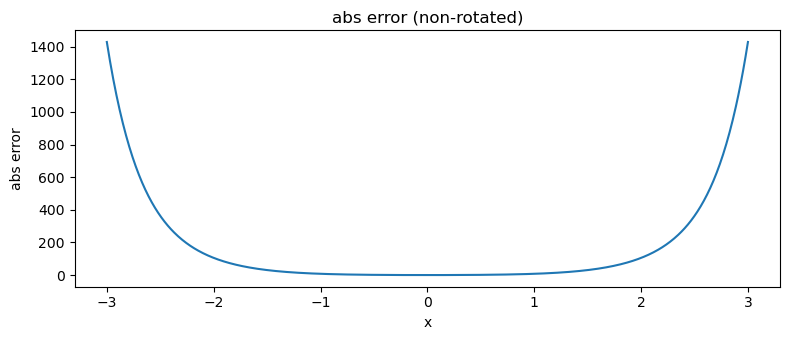

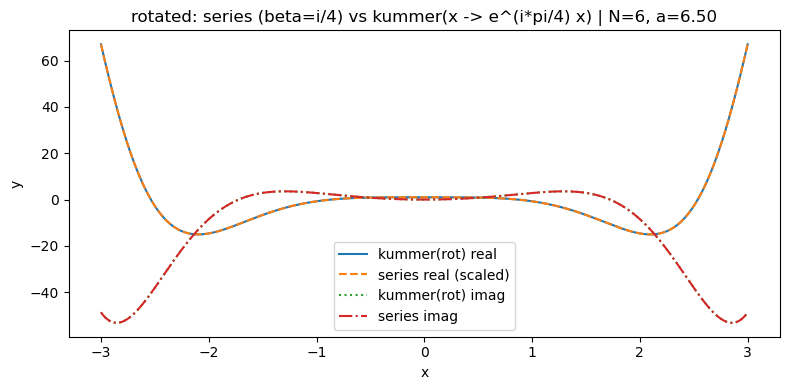

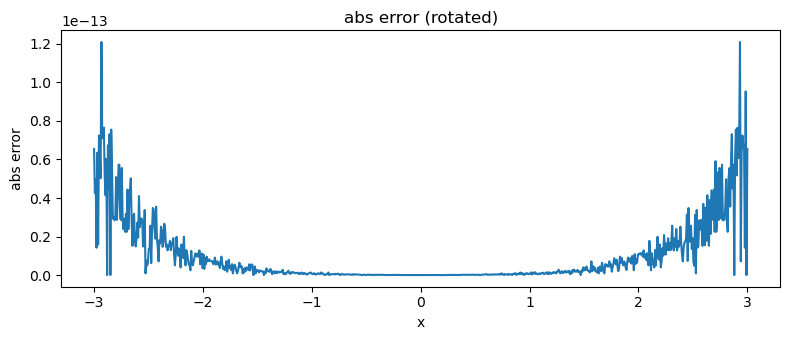

{'a': 6.5, 'C_nonrot': (1+0j), 'C_rot': (1+0j), 'max_err_nonrot': 1429.0361858736583, 'max_err_rot': 1.2100106776761097e-13}


In [14]:

import numpy as np
import mpmath as mp
import matplotlib.pyplot as plt


def a_from_N_even(N: int) -> float:
    # standard Weber parameter on real axis for even truncation degree N
    return 0.5*(2*N + 1)

def get_coeffs(N: int):
    # original even-parity recurrence with -i (kept as given)
    c = [0j]*(2*N + 1)
    c[0] = 1.0 + 0j
    c[1] = 0.0 + 0j
    for s in range(0, 2*N, 2):
        num = -1j*(2*s + 1)/2.0 + 1j*(2*N + 1)/2.0
        den = (s + 2)*(s + 1)
        c[s+2] = (num/den)*c[s]
    return np.array(c, dtype=complex)

def series_even(x, N: int, beta_is_imag=True):
    # y(x) = exp((i/4)*x^2) * sum c_k x^k  (if beta_is_imag=True)
    x = np.asarray(x, dtype=float)
    c = get_coeffs(N)
    k = np.arange(len(c))[:, None]
    Xk = x[None,:] ** k
    poly = (c[:,None]*Xk).sum(axis=0)
    pref = np.exp((1j if beta_is_imag else 1.0)*0.25*x**2)
    return pref * poly


def kummer_even_real(a_std: float, x):
    # y = exp(+x^2/4) * 1F1( 1/4 - a/2 ; 1/2 ; -x^2/2 )
    x = np.asarray(x, dtype=float)
    A = 0.25 - 0.5*a_std
    B = 0.5
    Z = -0.5 * x**2
    f = np.vectorize(lambda z: mp.hyp1f1(A, B, z))
    return np.exp(+0.25*x**2) * np.array(f(Z), dtype=complex)

def kummer_even_rot(a_std: float, x):
    # rotate argument: x -> e^{i*pi/4} x
    # becomes exp(+i x^2/4) * 1F1( 1/4 - a/2 ; 1/2 ; -i x^2/2 )
    x = np.asarray(x, dtype=float)
    A = 0.25 - 0.5*a_std
    B = 0.5
    x2_rot = (np.exp(1j*np.pi/4)*x)**2  # i * x^2
    Z = -0.5 * x2_rot
    f = np.vectorize(lambda z: mp.hyp1f1(A, B, z))
    return np.exp(+0.25*x2_rot) * np.array(f(Z), dtype=complex)

#comparisoon
def compare_plots(N=6, x_span=(-3,3), n=801):
    a_std = a_from_N_even(N)
    x = np.linspace(x_span[0], x_span[1], n)

    # build series once (imaginary beta gauge)
    y_series = series_even(x, N, beta_is_imag=True)

    #non-rotated kummer (real axis) 
    y_kummer = kummer_even_real(a_std, x)
    i0 = np.argmin(np.abs(x))
    C1 = y_kummer[i0]/y_series[i0] if y_series[i0] != 0 else 1.0+0j
    y_series_scaled = C1*y_series
    err1 = np.abs(y_kummer - y_series_scaled)

    plt.figure(figsize=(8,4))
    plt.title(f"non-rotated: series (beta=i/4) vs real-axis kummer | N={N}, a={(2*N+1)/2:.2f}")
    plt.plot(x, y_kummer.real, label="kummer real")
    plt.plot(x, y_series_scaled.real, "--", label="series real (scaled)")
    plt.plot(x, y_kummer.imag, ":", label="kummer imag")
    plt.plot(x, y_series_scaled.imag, "-.", label="series imag")
    plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,3.5))
    plt.title("abs error (non-rotated)")
    plt.plot(x, err1); plt.xlabel("x"); plt.ylabel("abs error"); plt.tight_layout(); plt.show()

    # --- rotated kummer (x -> e^{i*pi/4} x) ---
    y_kummer_rot = kummer_even_rot(a_std, x)
    C2 = y_kummer_rot[i0]/y_series[i0] if y_series[i0] != 0 else 1.0+0j
    y_series_scaled2 = C2*y_series
    err2 = np.abs(y_kummer_rot - y_series_scaled2)

    plt.figure(figsize=(8,4))
    plt.title(f"rotated: series (beta=i/4) vs kummer(x -> e^(i*pi/4) x) | N={N}, a={(2*N+1)/2:.2f}")
    plt.plot(x, y_kummer_rot.real, label="kummer(rot) real")
    plt.plot(x, y_series_scaled2.real, "--", label="series real (scaled)")
    plt.plot(x, y_kummer_rot.imag, ":", label="kummer(rot) imag")
    plt.plot(x, y_series_scaled2.imag, "-.", label="series imag")
    plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,3.5))
    plt.title("abs error (rotated)")
    plt.plot(x, err2); plt.xlabel("x"); plt.ylabel("abs error"); plt.tight_layout(); plt.show()

    return dict(a=a_std, C_nonrot=C1, C_rot=C2, max_err_nonrot=float(np.max(err1)), max_err_rot=float(np.max(err2)))

# demo
out = compare_plots(N=6, x_span=(-3,3), n=801)
print(out)

